# Single-Cell RNA-seq Neuronal Cell Type Classification in Mouse

**Objective:** Predict the neuronal cell-type labels from single-cell RNA-seq expression profiles.
**Data Source:** https://brain-map.org/our-research/cell-types-taxonomies/cell-types-database-rna-seq-data

**You must set:**
- `DATA_PATH` to the downloaded Allen Brain Atlas mouse dataset (H5AD)
- `label_col` to the column in `adata.obs` containing cell-type labels

In [1]:
from pathlib import Path
import urllib.request
import pandas as pd
import numpy as np
import scipy.sparse as sp
import h5py
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 120


In [2]:
DATA_URL = "https://idk-etl-prod-download-bucket.s3.amazonaws.com/aibs_mouse_ctx-hpf_smart-seq/expression_matrix.hdf5"
DATA_PATH = Path("data/expression_matrix.hdf5")

DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

class SimpleAnnData:
    def __init__(self, X, obs=None, var=None):
        self.X = X
        self.obs = obs if obs is not None else pd.DataFrame(index=[str(i) for i in range(X.shape[0])])
        self.var = var if var is not None else pd.DataFrame(index=[str(i) for i in range(X.shape[1])])
        self.raw = None

    @property
    def n_obs(self):
        return self.X.shape[0]

    @property
    def n_vars(self):
        return self.X.shape[1]

    @property
    def obs_names(self):
        return self.obs.index

    @obs_names.setter
    def obs_names(self, values):
        self.obs.index = pd.Index(values).astype(str)

    @property
    def var_names(self):
        return self.var.index

    @var_names.setter
    def var_names(self, values):
        self.var.index = pd.Index(values).astype(str)

    def _positions(self, indexer, axis_index):
        if isinstance(indexer, slice):
            return indexer
        if isinstance(indexer, pd.Series):
            indexer = indexer.to_numpy()
        if isinstance(indexer, pd.Index):
            indexer = indexer.to_numpy()
        arr = np.asarray(indexer)
        if arr.dtype == bool:
            return arr
        if arr.dtype.kind in {"U", "S", "O"}:
            return axis_index.get_indexer(arr.astype(str))
        return arr

    def __getitem__(self, key):
        if isinstance(key, tuple):
            obs_key, var_key = key
        else:
            obs_key, var_key = key, slice(None)
        obs_pos = self._positions(obs_key, self.obs.index)
        var_pos = self._positions(var_key, self.var.index)
        X = self.X[obs_pos, :][:, var_pos]
        obs = self.obs.iloc[obs_pos].copy() if not isinstance(obs_pos, slice) else self.obs.iloc[obs_pos].copy()
        var = self.var.iloc[var_pos].copy() if not isinstance(var_pos, slice) else self.var.iloc[var_pos].copy()
        return SimpleAnnData(X, obs=obs, var=var)

    def copy(self):
        return SimpleAnnData(self.X.copy(), self.obs.copy(), self.var.copy())

    def __repr__(self):
        return f"SimpleAnnData object with n_obs x n_vars = {self.n_obs} x {self.n_vars}"


def remote_file_size(url):
    req = urllib.request.Request(url, method="HEAD")
    with urllib.request.urlopen(req) as resp:
        size = resp.headers.get("Content-Length")
    return int(size) if size is not None else None


def download_with_resume(url, path, chunk_size=1024 * 1024):
    existing = path.stat().st_size if path.exists() else 0
    req = urllib.request.Request(url)
    if existing > 0:
        req.add_header("Range", f"bytes={existing}-")
    with urllib.request.urlopen(req) as resp:
        total = resp.headers.get("Content-Length")
        total = int(total) + existing if total is not None else None
        mode = "ab" if existing > 0 else "wb"
        with open(path, mode) as f:
            downloaded = existing
            while True:
                chunk = resp.read(chunk_size)
                if not chunk:
                    break
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    pct = 100 * downloaded / total
                    print(f"Downloaded {downloaded / (1024**3):.2f} GB ({pct:.1f}%)", end="\r")
    print()


def decode_name_array(arr):
    if arr.dtype.kind in ("S", "O"):
        return np.array([
            x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else str(x)
            for x in arr
        ])
    return arr.astype(str)


def read_csc_group(g):
    shape = tuple(int(v) for v in g["dims"][()])
    data = g["x"][()]
    indices = np.empty(g["i"].shape, dtype=np.int32)
    g["i"].read_direct(indices)
    indptr = g["p"][()].astype(np.int64, copy=False)
    return sp.csc_matrix((data, indices, indptr), shape=shape)


def load_allen_expression(path):
    with h5py.File(path, "r") as f:
        sample_names = decode_name_array(f["sample_names"][()])
        gene_names = decode_name_array(f["gene_names"][()])
        # t_exon is stored as genes x cells in CSC format; transpose gives cells x genes.
        X = read_csc_group(f["data/t_exon"]).T.tocsr()
    obs = pd.DataFrame(index=pd.Index(sample_names, name="sample_name"))
    var = pd.DataFrame(index=pd.Index(gene_names, name="gene_name"))
    return SimpleAnnData(X, obs=obs, var=var)


if not DATA_PATH.exists():
    download_with_resume(DATA_URL, DATA_PATH)

adata = load_allen_expression(DATA_PATH)
print(adata)
adata.obs.head()


SimpleAnnData object with n_obs x n_vars = 73363 x 45768


""
sample_name
US-1250273_E1_S37
US-1250273_E2_S01
US-1250273_E2_S02
US-1250273_E2_S03
US-1250273_E2_S04


In [3]:
META_URL = "https://idk-etl-prod-download-bucket.s3.amazonaws.com/aibs_mouse_ctx-hpf_smart-seq/metadata.csv"
META_PATH = Path("data/metadata.csv")

if not META_PATH.exists():
    urllib.request.urlretrieve(META_URL, META_PATH)

meta = pd.read_csv(META_PATH, low_memory=False)
print("Metadata columns:", list(meta.columns))
print(meta.head())

id_candidates = [
    "sample_name",
    "cell_id",
    "sample_id",
    "cell_name",
    "cell",
    "Cell",
    "CellID",
    "sample",
    "cell_label",
]
id_col = next((c for c in id_candidates if c in meta.columns), None)
if id_col is None:
    raise ValueError("No obvious cell id column found in metadata.csv")

meta = meta.set_index(id_col)
adata.obs = adata.obs.join(meta, how="left")
print("Merged metadata into adata.obs")


Metadata columns: ['sample_name', 'donor_sex_id', 'donor_sex_label', 'donor_sex_color', 'region_id', 'region_label', 'region_color', 'platform_label', 'cluster_order', 'cluster_label', 'cluster_color', 'subclass_order', 'subclass_label', 'subclass_color', 'neighborhood_id', 'neighborhood_label', 'neighborhood_color', 'class_order', 'class_label', 'class_color', 'exp_component_name', 'external_donor_name_label', 'full_genotype_label', 'facs_population_plan_label', 'injection_roi_label', 'injection_materials_label', 'injection_method_label', 'injection_type_label', 'full_genotype_id', 'full_genotype_color', 'external_donor_name_id', 'external_donor_name_color', 'facs_population_plan_id', 'facs_population_plan_color', 'injection_materials_id', 'injection_materials_color', 'injection_method_id', 'injection_method_color', 'injection_roi_id', 'injection_roi_color', 'injection_type_id', 'injection_type_color', 'cell_type_accession_label', 'cell_type_alias_label', 'cell_type_alt_alias_label', 

In [4]:
preferred_label_cols = [
    "subclass_label",
    "cell_type_alias_label",
    "cell_type_designation_label",
    "cluster_label",
    "class_label",
]
label_cols = [c for c in adata.obs.columns if c.endswith("_label")]
print("Label-like columns:", label_cols)

label_col = next((c for c in preferred_label_cols if c in adata.obs.columns), None)
if label_col is None:
    label_col = label_cols[0] if label_cols else "cell_type"
if label_col not in adata.obs.columns:
    raise ValueError("No label column found. Choose a column from adata.obs and set label_col.")
print("Using label column:", label_col)

adata = adata[~adata.obs[label_col].isna()].copy()

class_counts = adata.obs[label_col].value_counts()
print(class_counts.head(10))

min_cells = 50
keep_labels = class_counts[class_counts >= min_cells].index
adata = adata[adata.obs[label_col].isin(keep_labels)].copy()

# Keep the notebook runnable on typical laptops while preserving class balance.
max_cells_per_class = 300
sampled_idx = (
    adata.obs
    .groupby(label_col, group_keys=False, observed=True)
    .apply(lambda df: df.sample(n=min(len(df), max_cells_per_class), random_state=RANDOM_STATE))
    .index
)
adata = adata[sampled_idx].copy()

print("Classes kept:", len(keep_labels))
print("Cells kept after balanced cap:", adata.n_obs)


Label-like columns: ['donor_sex_label', 'region_label', 'platform_label', 'cluster_label', 'subclass_label', 'neighborhood_label', 'class_label', 'external_donor_name_label', 'full_genotype_label', 'facs_population_plan_label', 'injection_roi_label', 'injection_materials_label', 'injection_method_label', 'injection_type_label', 'cell_type_accession_label', 'cell_type_alias_label', 'cell_type_alt_alias_label', 'cell_type_designation_label', 'cortical_layer_label']
Using label column: subclass_label


subclass_label
L4/5 IT CTX    10854
L6 CT CTX       6350
Vip             6329
L2/3 IT CTX     6003
Sst             5511
Lamp5           4805
L6 IT CTX       4658
Pvalb           4109
L5 IT CTX       3750
DG              2474
Name: count, dtype: int64


Classes kept: 38
Cells kept after balanced cap: 9685


In [5]:
def _axis_sum(X, axis):
    return np.asarray(X.sum(axis=axis)).ravel()


def filter_genes(adata, min_cells=1):
    detected = np.asarray((adata.X > 0).sum(axis=0)).ravel()
    return adata[:, detected >= min_cells].copy()


def filter_cells(adata, min_counts=None, min_genes=None):
    keep = np.ones(adata.n_obs, dtype=bool)
    if min_counts is not None:
        keep &= _axis_sum(adata.X, axis=1) >= min_counts
    if min_genes is not None:
        keep &= np.asarray((adata.X > 0).sum(axis=1)).ravel() >= min_genes
    return adata[keep, :].copy()


def calculate_qc_metrics(adata, qc_var="mt"):
    total = _axis_sum(adata.X, axis=1)
    mt_mask = adata.var[qc_var].to_numpy(dtype=bool)
    mt_counts = _axis_sum(adata.X[:, mt_mask], axis=1) if mt_mask.any() else np.zeros(adata.n_obs)
    adata.obs["total_counts"] = total
    adata.obs["n_genes_by_counts"] = np.asarray((adata.X > 0).sum(axis=1)).ravel()
    adata.obs["pct_counts_mt"] = np.divide(mt_counts, total, out=np.zeros_like(mt_counts), where=total > 0) * 100


adata = filter_genes(adata, min_cells=10)
adata = filter_cells(adata, min_counts=1000)
adata = filter_cells(adata, min_genes=200)

adata.var["mt"] = adata.var_names.str.startswith("mt-") | adata.var_names.str.startswith("Mt-")
calculate_qc_metrics(adata, qc_var="mt")
adata = adata[adata.obs.pct_counts_mt < 10, :].copy()
print(adata)


SimpleAnnData object with n_obs x n_vars = 9685 x 36216


In [6]:
def normalize_total(adata, target_sum=1e4):
    counts = _axis_sum(adata.X, axis=1)
    scale = np.divide(target_sum, counts, out=np.ones_like(counts), where=counts > 0)
    adata.X = sp.diags(scale).dot(adata.X).tocsr() if sp.issparse(adata.X) else adata.X * scale[:, None]


def log1p(adata):
    if sp.issparse(adata.X):
        adata.X = adata.X.copy()
        adata.X.data = np.log1p(adata.X.data)
    else:
        adata.X = np.log1p(adata.X)


normalize_total(adata, target_sum=1e4)
log1p(adata)
adata.raw = adata.copy()


In [7]:
def highly_variable_genes(adata, n_top_genes=2000):
    X = adata.X
    if sp.issparse(X):
        mean = np.asarray(X.mean(axis=0)).ravel()
        X2 = X.copy()
        X2.data **= 2
        mean_sq = np.asarray(X2.mean(axis=0)).ravel()
        var = mean_sq - mean ** 2
    else:
        var = X.var(axis=0)
    n_top = min(n_top_genes, adata.n_vars)
    top_idx = np.argsort(var)[-n_top:]
    hv = np.zeros(adata.n_vars, dtype=bool)
    hv[top_idx] = True
    adata.var["highly_variable"] = hv
    adata.var["variance"] = var


highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable].copy()
print(adata)


SimpleAnnData object with n_obs x n_vars = 9685 x 2000


In [8]:
X = adata.X
if sp.issparse(X):
    X = X.toarray()

y = adata.obs[label_col].astype(str).values
labels = np.unique(y)

rng = np.random.default_rng(RANDOM_STATE)
train_idx = []
val_idx = []
test_idx = []

for label in labels:
    idx = np.where(y == label)[0]
    rng.shuffle(idx)
    n = len(idx)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_idx.extend(idx[:n_train])
    val_idx.extend(idx[n_train:n_train + n_val])
    test_idx.extend(idx[n_train + n_val:])

train_idx = rng.permutation(train_idx)
val_idx = rng.permutation(val_idx)
test_idx = rng.permutation(test_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

In [9]:
def standardize_fit(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0
    return mean, std


def standardize_apply(X, mean, std):
    return (X - mean) / std


def evaluate_model(y_true, y_pred, labels, title):
    metrics = {
        "model": title,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }
    print(f"{title} accuracy: {metrics['accuracy']:.4f}")
    print(f"{title} balanced accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"{title} macro F1: {metrics['macro_f1']:.4f}")

    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{title} Confusion Matrix (Normalized)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_yticklabels(labels, fontsize=6)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    return metrics


Validation (Logistic Regression) accuracy: 0.9765
Validation (Logistic Regression) balanced accuracy: 0.9796
Validation (Logistic Regression) macro F1: 0.9792


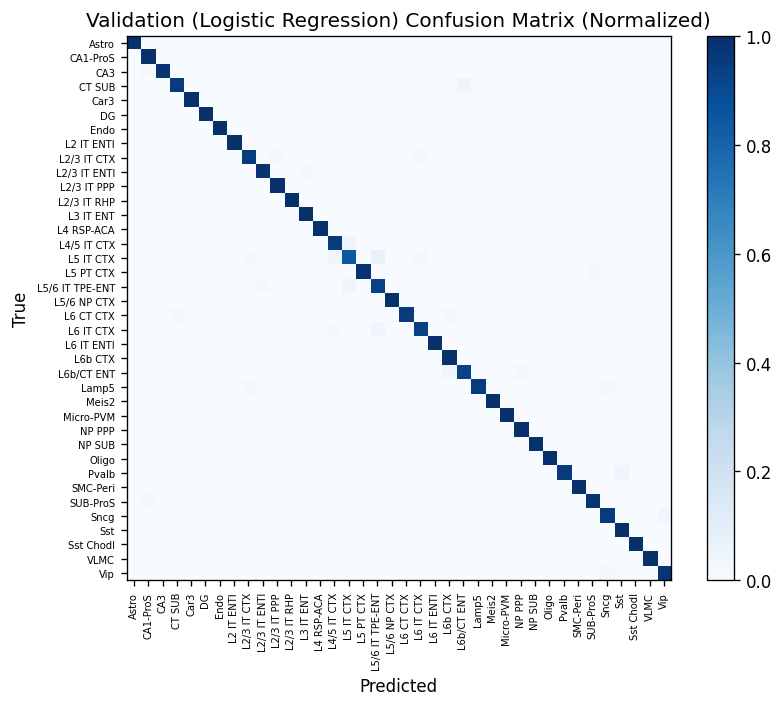

In [10]:
mean, std = standardize_fit(X_train)
X_train_s = standardize_apply(X_train, mean, std)
X_val_s = standardize_apply(X_val, mean, std)
X_test_s = standardize_apply(X_test, mean, std)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_STATE,
)
log_reg.fit(X_train_s, y_train)

lr_val_pred = log_reg.predict(X_val_s)
lr_val_metrics = evaluate_model(y_val, lr_val_pred, labels, "Validation (Logistic Regression)")


Validation (Extra Trees Ensemble) accuracy: 0.9758
Validation (Extra Trees Ensemble) balanced accuracy: 0.9768
Validation (Extra Trees Ensemble) macro F1: 0.9777


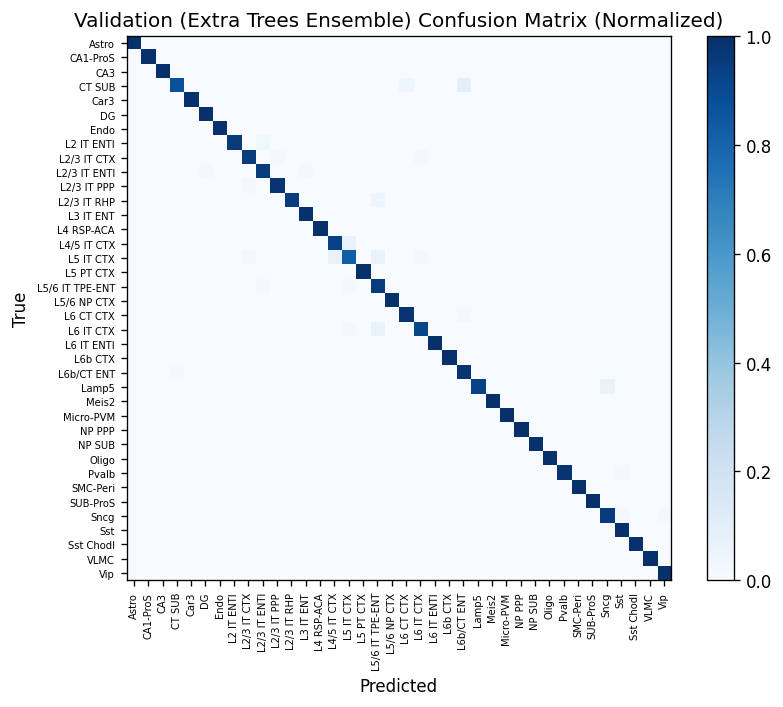

In [11]:
extra_trees = ExtraTreesClassifier(
    n_estimators=160,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
extra_trees.fit(X_train, y_train)

et_val_pred = extra_trees.predict(X_val)
et_val_metrics = evaluate_model(y_val, et_val_pred, labels, "Validation (Extra Trees Ensemble)")


Test (Logistic Regression) accuracy: 0.9802
Test (Logistic Regression) balanced accuracy: 0.9827
Test (Logistic Regression) macro F1: 0.9818


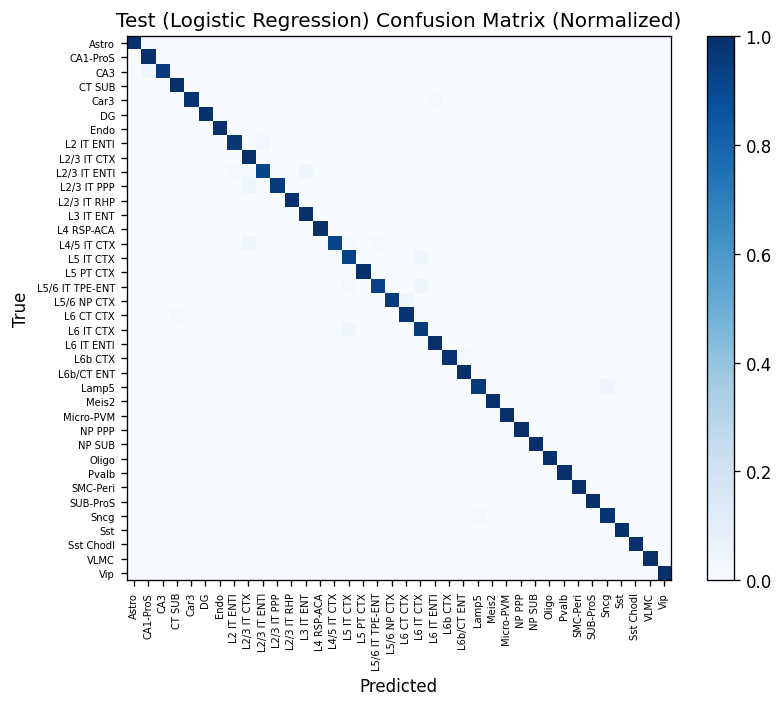

Test (Extra Trees Ensemble) accuracy: 0.9748
Test (Extra Trees Ensemble) balanced accuracy: 0.9758
Test (Extra Trees Ensemble) macro F1: 0.9750


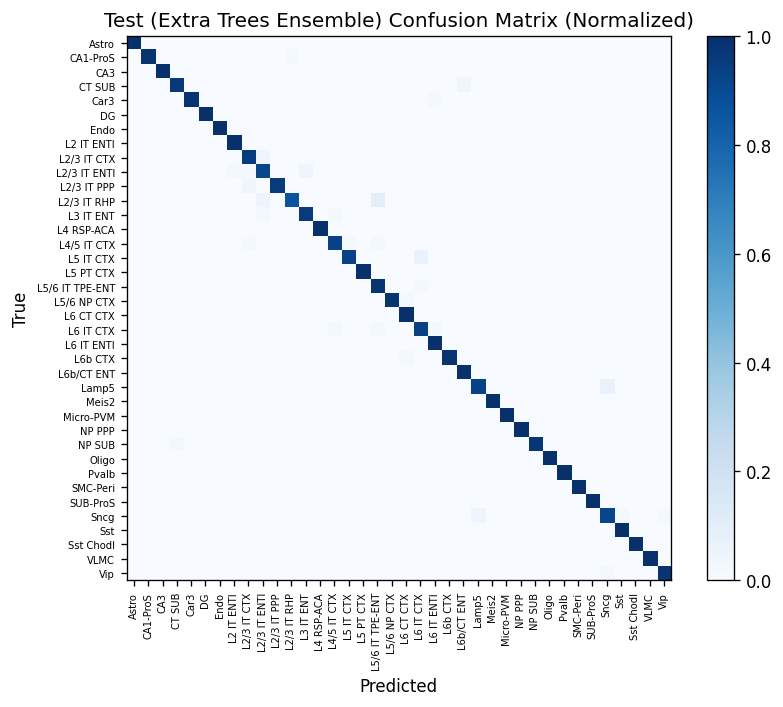

,model,accuracy,balanced_accuracy,macro_f1
0,Validation (Logistic Regression),0.976471,0.979558,0.979174
1,Validation (Extra Trees Ensemble),0.975779,0.976768,0.977739
2,Test (Logistic Regression),0.980232,0.982749,0.981844
3,Test (Extra Trees Ensemble),0.974778,0.975800,0.974991


In [12]:
lr_test_pred = log_reg.predict(X_test_s)
et_test_pred = extra_trees.predict(X_test)

lr_test_metrics = evaluate_model(y_test, lr_test_pred, labels, "Test (Logistic Regression)")
et_test_metrics = evaluate_model(y_test, et_test_pred, labels, "Test (Extra Trees Ensemble)")

results = pd.DataFrame([
    lr_val_metrics,
    et_val_metrics,
    lr_test_metrics,
    et_test_metrics,
])
results


In [13]:
gene_vars = np.var(X_train_s, axis=0)
top_idx = np.argsort(gene_vars)[-15:]
top_genes = adata.var_names[top_idx]
print("Top variable genes:", list(top_genes))

feature_importance_idx = np.argsort(extra_trees.feature_importances_)[-15:]
important_genes = adata.var_names[feature_importance_idx]
print("Top ensemble feature-importance genes:", list(important_genes))


Top variable genes: ['Htr3a', 'Sparc', 'Vip', 'Gja1', 'Acta2', 'Slc1a3', 'Gjb6', 'Cfh', 'S100a16', 'Flt1', 'Tac1', 'Zfp36', 'S1pr1', 'Tm4sf1', 'Ly6a']
Top ensemble feature-importance genes: ['Ptn', 'Olfm1', 'Lamp5', 'Fam19a1', 'Crym', 'Meis2', 'Hs3st4', 'Cplx3', 'Cck', 'Dcn', 'Sst', 'Synpr', 'Mef2c', 'Tshz2', 'Pcp4']
